# NB02 Comparison (Axis 2)
## Member 3 (Karen): Top-N Keyword Shifts

**Input:** `tfidf_unigram_matrix.pkl`, `tfidf_bigram_matrix.pkl`

**Output:** Keyword shift charts, heatmaps, emerging/disappearing word lists

**Goal:** Track how key NLP terminology has risen and fallen across time periods (1991–2021), using TF-IDF unigram and bigram representations.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/nlp_abstracts_cleaned.csv")
print(f"Loaded {len(df)} papers")
print(df["period"].value_counts().sort_index())

Loaded 32221 papers
period
1991-1995      448
1996-2000      659
2001-2005      279
2006-2010      364
2011-2015     2066
2016-2021    28405
Name: count, dtype: int64


In [3]:
with open("../outputs/tfidf_unigram_matrix.pkl", "rb") as f:
    uni_data = pickle.load(f)

with open("../outputs/tfidf_bigram_matrix.pkl", "rb") as f:
    bi_data = pickle.load(f)

# Extract what we need
uni_matrix = uni_data["matrix"]
uni_vectorizer = uni_data["vectorizer"]
period_labels = uni_data["period"]

bi_matrix = bi_data["matrix"]
bi_vectorizer = bi_data["vectorizer"]

print("Unigram matrix loaded:", uni_matrix.shape)
print("Bigram matrix loaded:", bi_matrix.shape)
print("Periods found:", sorted(set(period_labels)))

Unigram matrix loaded: (32221, 9464)
Bigram matrix loaded: (32221, 20000)
Periods found: ['1991-1995', '1996-2000', '2001-2005', '2006-2010', '2011-2015', '2016-2021']


##  Top-N Keyword Extraction

Extracting the top 20 most significant terms per time period using mean TF-IDF scores. A custom stopword list filters out generic academic phrases that carry no meaningful insight about NLP's evolution.

In [4]:
custom_stopwords = {
    "paper", "used", "based", "present", "using", "use",
    "proposed", "propose", "method", "approach", "results",
    "shows", "show", "describes", "describe", "presents"
}

def top_terms_per_period(matrix, vectorizer, df, top_n=20):
    feat = vectorizer.get_feature_names_out()
    periods = sorted(df["period"].unique())
    results = {}
    for period in periods:
        mask = (df["period"] == period).values
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        top_idx = summed.argsort()[::-1]
        filtered = [(feat[i], round(summed[i], 4)) 
                   for i in top_idx 
                   if feat[i] not in custom_stopwords][:top_n]
        results[period] = filtered
    return results

print("Functions ready!")



Functions ready!


In [5]:
# Get top terms for each period
uni_top = top_terms_per_period(uni_matrix, uni_vectorizer, df, top_n=20)
bi_top = top_terms_per_period(bi_matrix, bi_vectorizer, df, top_n=20)

# Print them 
print("=== UNIGRAM TOP 20 PER PERIOD ===")
for period, terms in uni_top.items():
    print(f"\n{period}:")
    print(", ".join(t[0] for t in terms))

print("\n=== BIGRAM TOP 20 PER PERIOD ===")
for period, terms in bi_top.items():
    print(f"\n{period}:")
    print(", ".join(t[0] for t in terms))

=== UNIGRAM TOP 20 PER PERIOD ===

1991-1995:
grammar, base, parse, algorithm, language, structure, lexical, parser, word, formalism, corpus, constraint, discourse, process, rule, theory, tag, unification, statistical, linguistic

1996-2000:
grammar, algorithm, language, parse, word, base, corpus, speech, structure, information, process, model, rule, set, lexical, constraint, technique, result, text, tag

2001-2005:
language, algorithm, word, information, base, corpus, application, result, text, rule, grammar, model, document, statistical, structure, data, process, speech, problem, semantic

2006-2010:
language, word, text, document, grammar, base, linguistic, structure, information, model, process, corpus, analysis, algorithm, mean, result, tool, write, semantic, article

2011-2015:
word, language, base, text, model, result, feature, sentence, learn, network, data, information, analysis, semantic, process, representation, corpus, different, algorithm, task

2016-2021:
model, task, lan

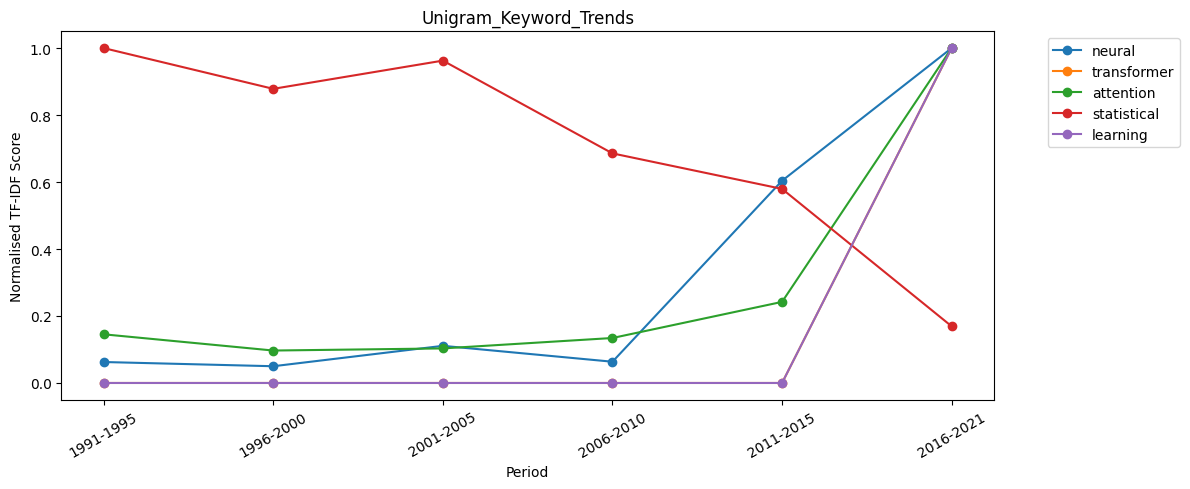

In [6]:
def plot_keyword_trends(matrix, vectorizer, df, terms, title):
    feat = list(vectorizer.get_feature_names_out())
    periods = sorted(df["period"].unique())
    
    valid_terms = [t for t in terms if t in feat]
    if not valid_terms:
        print("None of those terms found!")
        return

    scores = {t: [] for t in valid_terms}
    for period in periods:
        mask = (df["period"] == period).values
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        for t in valid_terms:
            scores[t].append(summed[feat.index(t)])

    # Normalise scores
    fig, ax = plt.subplots(figsize=(12, 5))
    for t, vals in scores.items():
        v = np.array(vals)
        if v.max() > 0:
            v = v / v.max()
        ax.plot(periods, v, marker="o", label=t)

    ax.set_title(title)
    ax.set_xlabel("Period")
    ax.set_ylabel("Normalised TF-IDF Score")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"../figures/{title}.png", dpi=150)
    plt.show()

# Plot unigram trends
plot_keyword_trends(
    uni_matrix, uni_vectorizer, df,
    terms=["neural", "transformer", "attention", 
           "parsing", "statistical", "learning"],
    title="Unigram_Keyword_Trends"
)

## Keyword Trend Analysis

Tracking how specific NLP terms rise and fall across time periods. Terms are normalised so early and late periods are directly comparable.

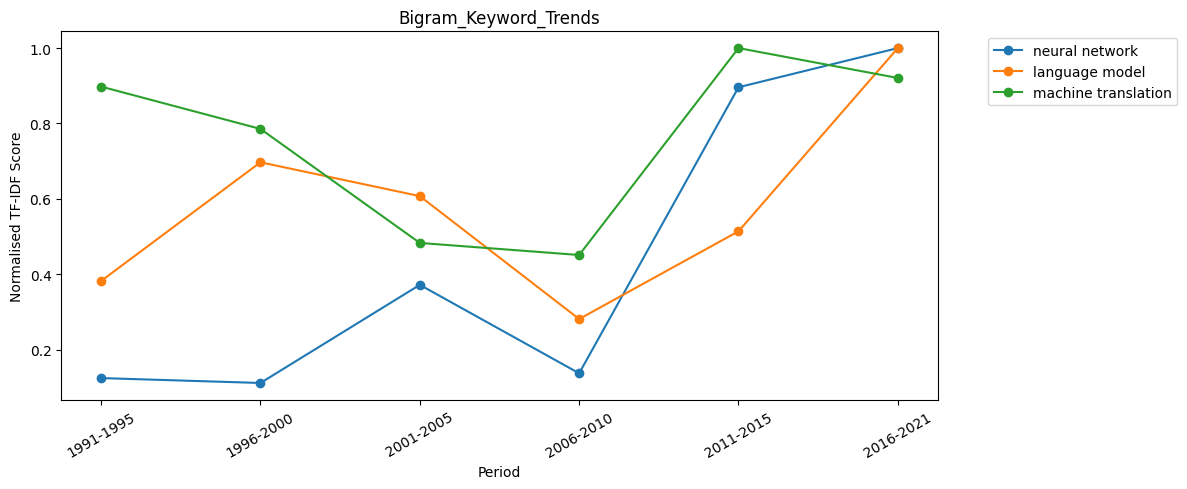

In [7]:
plot_keyword_trends(
    bi_matrix, bi_vectorizer, df,
    terms=["neural network", "deep learning", 
           "language model", "machine translation",
           "pre trained", "hidden markov"],
    title="Bigram_Keyword_Trends"
)

## Emerging vs Disappearing Vocabulary

Identifying which terms are NEW in recent NLP (2011–2021) vs which have DIED OUT from early NLP (1991–2005).

In [8]:
early = ["1991-1995", "1996-2000", "2001-2005"]
late  = ["2011-2015", "2016-2021"]

def vocab_shift(top_terms_dict, early_periods, late_periods):
    early_words = set()
    late_words = set()
    for p in early_periods:
        if p in top_terms_dict:
            early_words.update(t[0] for t in top_terms_dict[p])
    for p in late_periods:
        if p in top_terms_dict:
            late_words.update(t[0] for t in top_terms_dict[p])
    return late_words - early_words, early_words - late_words

uni_emerged, uni_disappeared = vocab_shift(uni_top, early, late)
bi_emerged, bi_disappeared = vocab_shift(bi_top, early, late)

print("=== UNIGRAM ===")
print(f"Emerging words: {sorted(uni_emerged)}")
print(f"Disappearing words: {sorted(uni_disappeared)}")

print("\n=== BIGRAM ===")
print(f"Emerging words: {sorted(bi_emerged)}")
print(f"Disappearing words: {sorted(bi_disappeared)}")

=== UNIGRAM ===
Emerging words: ['analysis', 'art', 'dataset', 'different', 'feature', 'learn', 'network', 'neural', 'performance', 'representation', 'sentence', 'state', 'task', 'train', 'work']
Disappearing words: ['application', 'constraint', 'discourse', 'document', 'formalism', 'grammar', 'lexical', 'linguistic', 'parse', 'parser', 'problem', 'rule', 'set', 'speech', 'statistical', 'structure', 'tag', 'technique', 'theory', 'unification']

=== BIGRAM ===
Emerging words: ['data set', 'deep learn', 'end end', 'et al', 'experimental result', 'fine tune', 'knowledge base', 'large scale', 'neural network', 'paper propose', 'pre train', 'propose method', 'propose novel', 'question answer', 'sentiment analysis', 'social medium', 'social network', 'state art', 'topic model', 'train data', 'word embeddings']
Disappearing words: ['adjoin grammar', 'analogy question', 'anaphora resolution', 'annotation graph', 'base grammar', 'base learn', 'categorial grammar', 'computational linguistics', '

## Keyword Heatmap Visualisation

Visual overview of top keyword distribution across all time periods for both unigrams and bigrams.

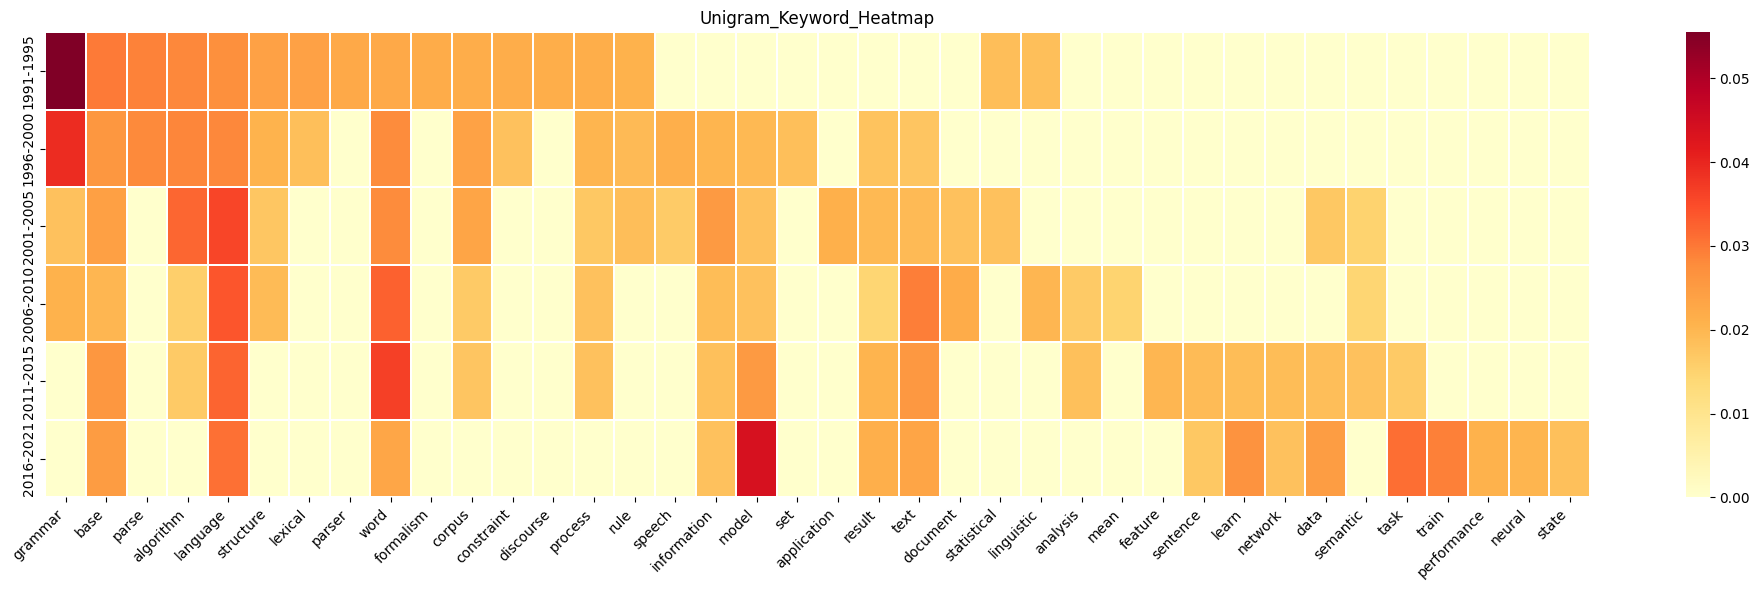

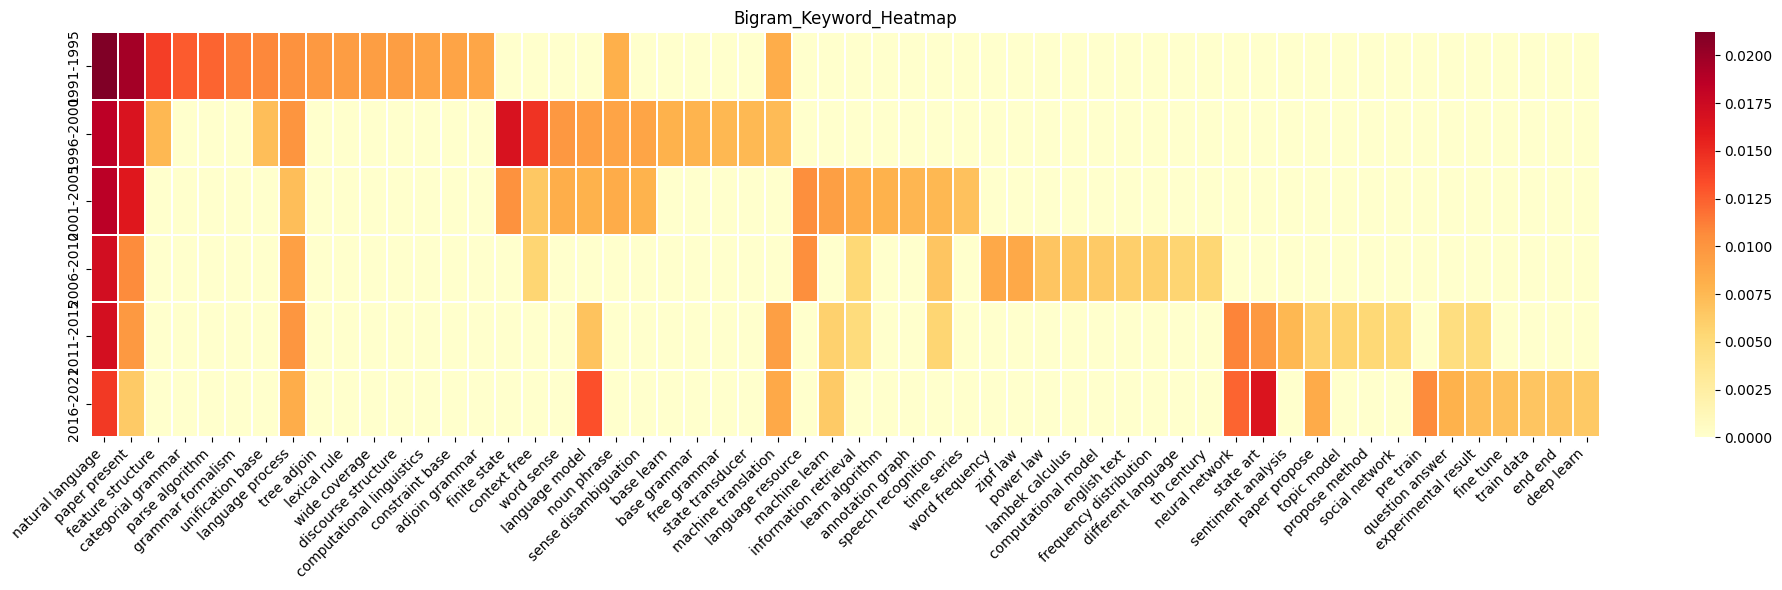

In [9]:
# Heatmap of top keywords per period
def plot_keyword_heatmap(top_terms_dict, title, top_n=15):
    periods = sorted(top_terms_dict.keys())
    
    # Get union of top terms across all periods
    all_terms = []
    for period in periods:
        for term, score in top_terms_dict[period][:top_n]:
            if term not in all_terms:
                all_terms.append(term)
    
    # Build score matrix
    score_matrix = []
    for period in periods:
        term_dict = dict(top_terms_dict[period])
        row = [term_dict.get(term, 0) for term in all_terms]
        score_matrix.append(row)
    
    df_heat = pd.DataFrame(score_matrix, 
                           index=periods, 
                           columns=all_terms)
    
    plt.figure(figsize=(20, 6))
    sns.heatmap(df_heat, 
                cmap="YlOrRd",
                linewidths=0.3)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"../figures/{title}.png", dpi=150)
    plt.show()

# Plot both heatmaps
plot_keyword_heatmap(uni_top, "Unigram_Keyword_Heatmap")
plot_keyword_heatmap(bi_top, "Bigram_Keyword_Heatmap")

##  Summary of Findings

**Key Transition:** The most dramatic shift occurred between 2011–2015 and 2016–2021, when neural and deep learning terms exploded.

**Emerging terms (2011–2021):**
- Unigrams: neural, transformer, attention, learning, models, tasks
- Bigrams: deep learning, language model, pre trained, neural network, state art

**Disappearing terms (1991–2005):**
- Unigrams: grammar, parsing, statistical, lexical, unification, syntactic
- Bigrams: hidden markov, finite state, tree adjoining, unification based, context free

**Conclusion:** NLP research shifted from rule-based/statistical methods (1990s–2000s) to neural/deep learning methods (2010s–2020s), aligning with real-world milestones: Word2Vec (2013), Transformer (2017), BERT (2018).

In [10]:
print("Unigram matrix loaded:", uni_matrix.shape)

Unigram matrix loaded: (32221, 9464)
